In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/analysis.csv")
df = df[["fluid_balance", "cvp", "diuretics_given", 
          "aki_24h_onset_stage", "mechvent_24h_onset",
          "aki_post24h_stage", "mechvent_post24h"]]

In [3]:
df.dtypes

fluid_balance          float64
cvp                    float64
diuretics_given          int64
aki_24h_onset_stage      int64
mechvent_24h_onset       int64
aki_post24h_stage        int64
mechvent_post24h         int64
dtype: object

In [4]:
df[["fluid_balance", "cvp", "diuretics_given"]].isnull().mean().round(3)

fluid_balance      0.001
cvp                0.714
diuretics_given    0.000
dtype: float64

In [5]:
df[["fluid_balance", "cvp", "diuretics_given"]].describe()

,fluid_balance,cvp,diuretics_given
count,32869.000000,9405.000000,32899.000000
mean,6876.447230,38.343434,0.300891
std,10396.773662,74.571397,0.458652
min,-139984.966353,-4.000000,0.000000
25%,1460.647250,13.000000,0.000000
50%,4241.132182,17.000000,0.000000
75%,8316.707053,22.000000,1.000000
max,178027.568084,1952.000000,1.000000


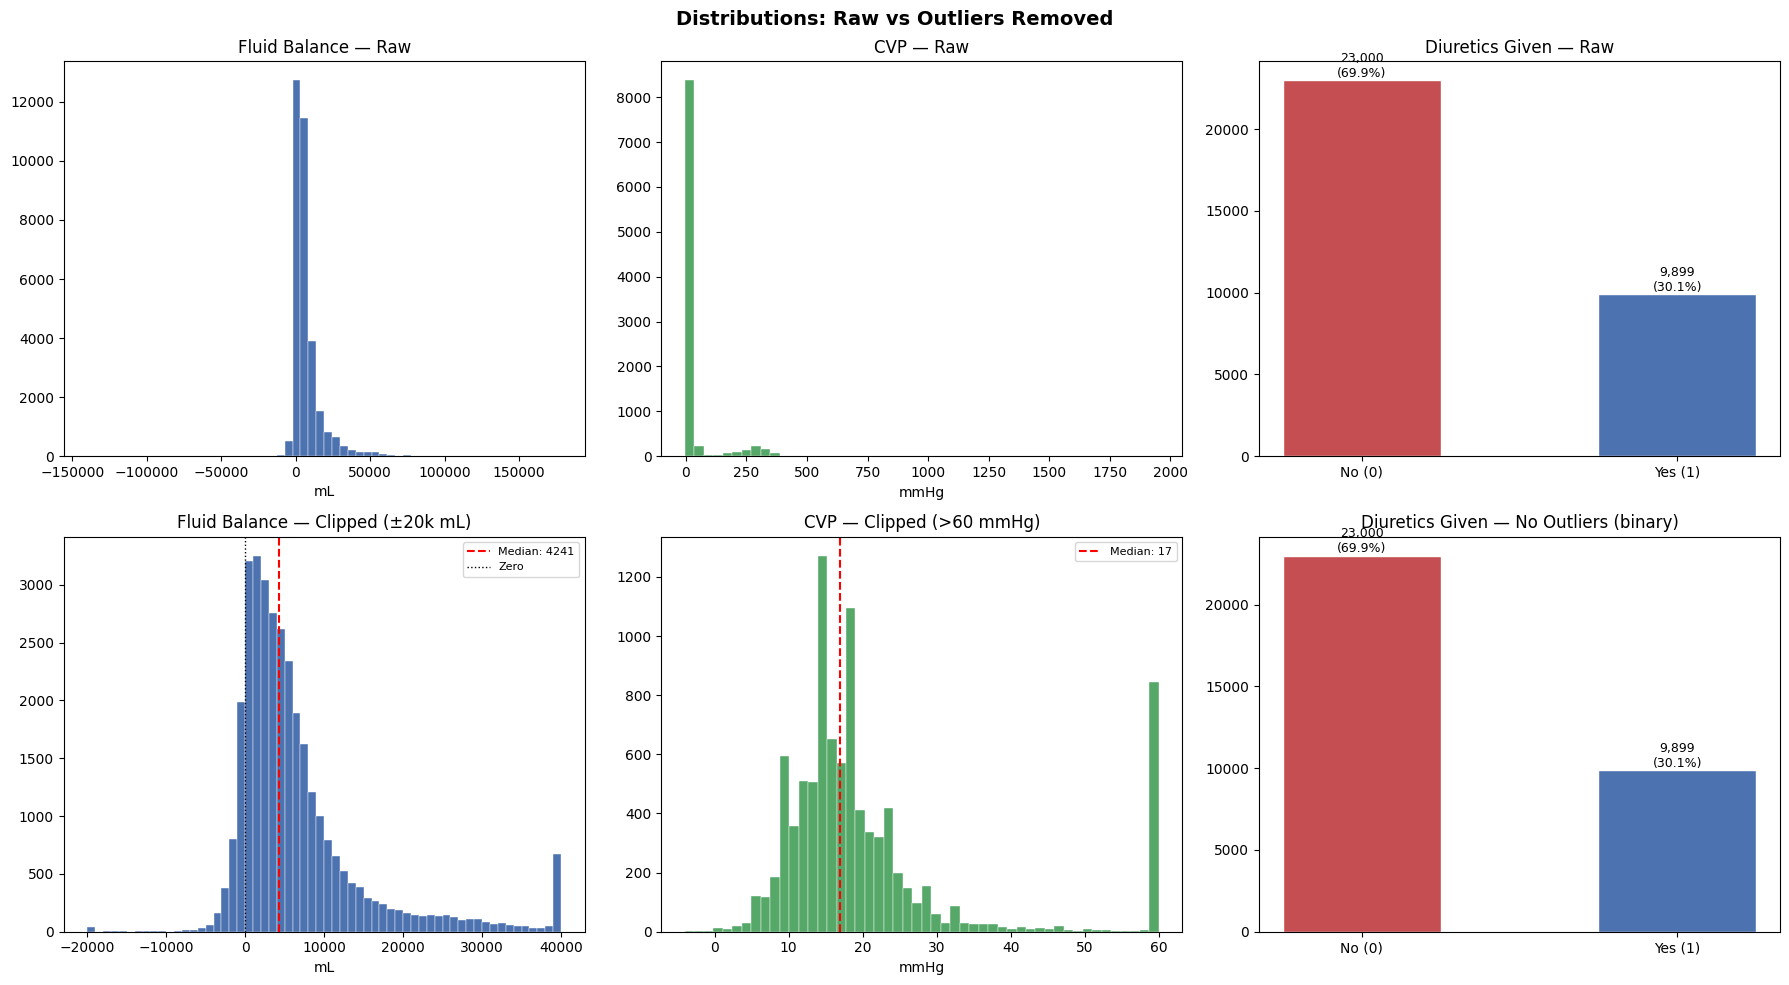

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distributions: Raw vs Outliers Removed", fontsize=14, fontweight="bold")

# Fluid Balance
axes[0,0].hist(df["fluid_balance"], bins=60, color="#4C72B0", edgecolor="white", linewidth=0.3)
axes[0,0].set_title("Fluid Balance — Raw")
axes[0,0].set_xlabel("mL")

fb_clean = df["fluid_balance"].clip(-20000, 40000)
axes[1,0].hist(fb_clean, bins=60, color="#4C72B0", edgecolor="white", linewidth=0.3)
axes[1,0].set_title("Fluid Balance — Clipped (±20k mL)")
axes[1,0].set_xlabel("mL")
axes[1,0].axvline(fb_clean.median(), color="red", linestyle="--", label=f"Median: {fb_clean.median():.0f}")
axes[1,0].axvline(0, color="black", linestyle=":", linewidth=1, label="Zero")
axes[1,0].legend(fontsize=8)

# CVP
axes[0,1].hist(df["cvp"].dropna(), bins=50, color="#55A868", edgecolor="white", linewidth=0.3)
axes[0,1].set_title("CVP — Raw")
axes[0,1].set_xlabel("mmHg")

cvp_clean = df["cvp"].clip(-5, 60)
axes[1,1].hist(cvp_clean.dropna(), bins=50, color="#55A868", edgecolor="white", linewidth=0.3)
axes[1,1].set_title("CVP — Clipped (>60 mmHg)")
axes[1,1].set_xlabel("mmHg")
axes[1,1].axvline(cvp_clean.median(), color="red", linestyle="--", label=f"Median: {cvp_clean.median():.0f}")
axes[1,1].legend(fontsize=8)

# Diuretics — same both rows, binary so no outliers
for row in [0, 1]:
    counts = df["diuretics_given"].value_counts().sort_index()
    axes[row,2].bar(["No (0)", "Yes (1)"], counts.values, 
                    color=["#C44E52", "#4C72B0"], edgecolor="white", width=0.5)
    axes[row,2].set_title("Diuretics Given" + (" — Raw" if row == 0 else " — No Outliers (binary)"))
    for i, v in enumerate(counts.values):
        axes[row,2].text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.show()
fig.savefig("../distributions.png", dpi=300)

In [18]:
print(df["cvp"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))
print(f"\nValues > 60:  {(df['cvp'] > 60).sum()}")
print(f"Values > 100: {(df['cvp'] > 100).sum()}")
print(f"Values > 200: {(df['cvp'] > 200).sum()}")

count    9405.000000
mean       38.343434
std        74.571397
min        -4.000000
1%          5.000000
5%          8.000000
25%        13.000000
50%        17.000000
75%        22.000000
95%       263.000000
99%       338.000000
max      1952.000000
Name: cvp, dtype: float64

Values > 60:  834
Values > 100: 758
Values > 200: 635


/var/folders/6p/5s7l8jtj05s_1p_1jxzg33480000gn/T/ipykernel_63866/4023683602.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Status", y="value",order=["No", "Yes"],
/var/folders/6p/5s7l8jtj05s_1p_1jxzg33480000gn/T/ipykernel_63866/4023683602.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Status", y="value",order=["No", "Yes"],
/var/folders/6p/5s7l8jtj05s_1p_1jxzg33480000gn/T/ipykernel_63866/4023683602.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Status", y="value",order=["No

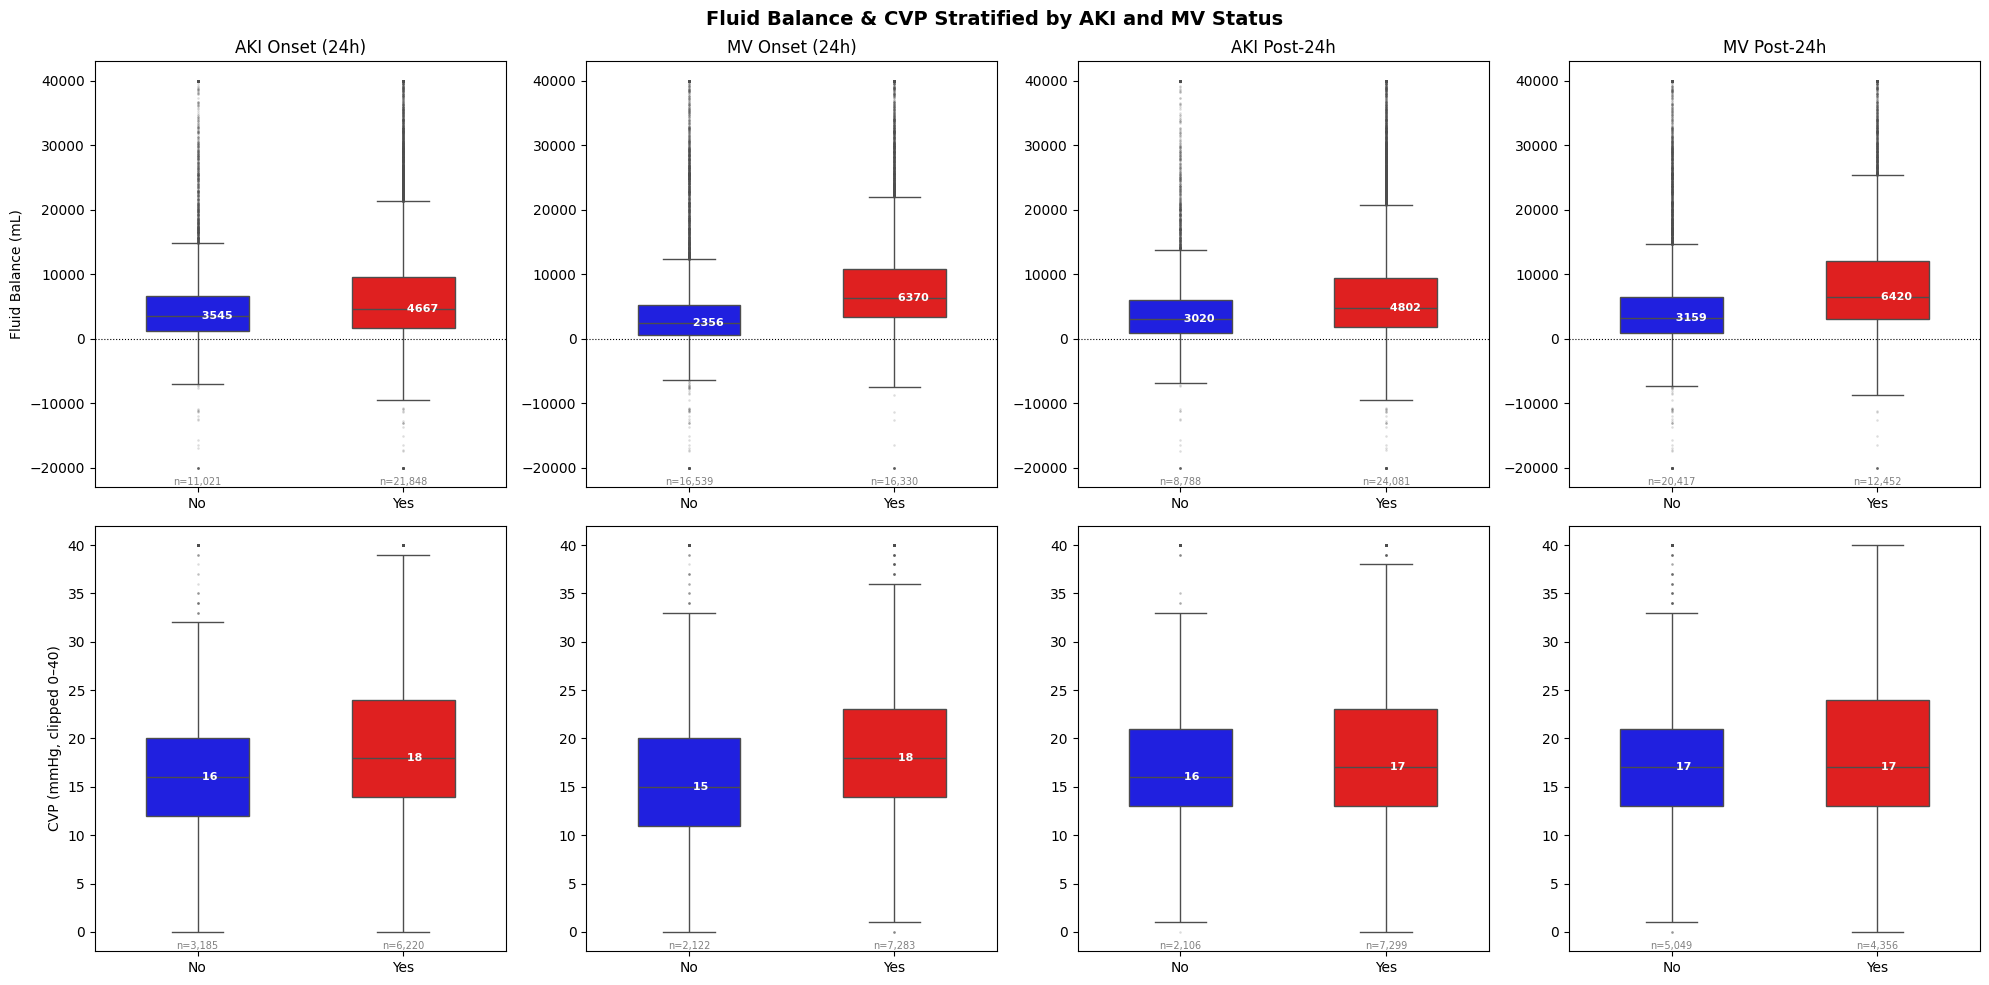

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Fluid Balance & CVP Stratified by AKI and MV Status", 
             fontsize=14, fontweight="bold")
df["aki_24h_binary"]   = (df["aki_24h_onset_stage"] > 0).astype(int)
df["aki_post24h_binary"] = (df["aki_post24h_stage"] > 0).astype(int)

outcomes= {
    "AKI Onset (24h)":  "aki_24h_binary",
    "MV Onset (24h)":   "mechvent_24h_onset",
    "AKI Post-24h":     "aki_post24h_binary",
    "MV Post-24h":      "mechvent_post24h",
}

fb_clean  = df["fluid_balance"].clip(-20000, 40000)
cvp_clean = df["cvp"].clip(0, 40)

for col, (outcome_label, outcome_col) in enumerate(outcomes.items()):
    for row, (var, var_label, series) in enumerate([
        ("fluid_balance", "Fluid Balance (mL)", fb_clean),
        ("cvp",           "CVP (mmHg, clipped 0–40)", cvp_clean),
    ]):
        ax = axes[row, col]
        plot_df = pd.DataFrame({
            "value":  series,
            "Status": df[outcome_col].map({0: "No", 1: "Yes"})
        }).dropna()

        sns.boxplot(data=plot_df, x="Status", y="value",order=["No", "Yes"],
                    palette=["blue", "red"], ax=ax, width=0.5,
                    flierprops=dict(marker=".", markersize=1.5, alpha=0.2))

        # Annotate medians
        for i, grp in enumerate(["No", "Yes"]):
            med = plot_df[plot_df["Status"] == grp]["value"].median()
            n   = (plot_df["Status"] == grp).sum()
            ax.text(i, ax.get_ylim()[0], f"n={n:,}", ha="center", 
                    fontsize=7, color="gray", va="bottom")
            ax.text(i, med, f" {med:.0f}", va="center", fontsize=8, 
                    fontweight="bold", color="white")

        ax.set_title(outcome_label if row == 0 else "")
        ax.set_ylabel(var_label if col == 0 else "")
        ax.set_xlabel("")
        if row == 0:
            ax.axhline(0, color="black", linestyle=":", linewidth=0.8)

plt.tight_layout()
plt.show()
fig.savefig("../fluid_cvp_stratified.png", dpi=300)


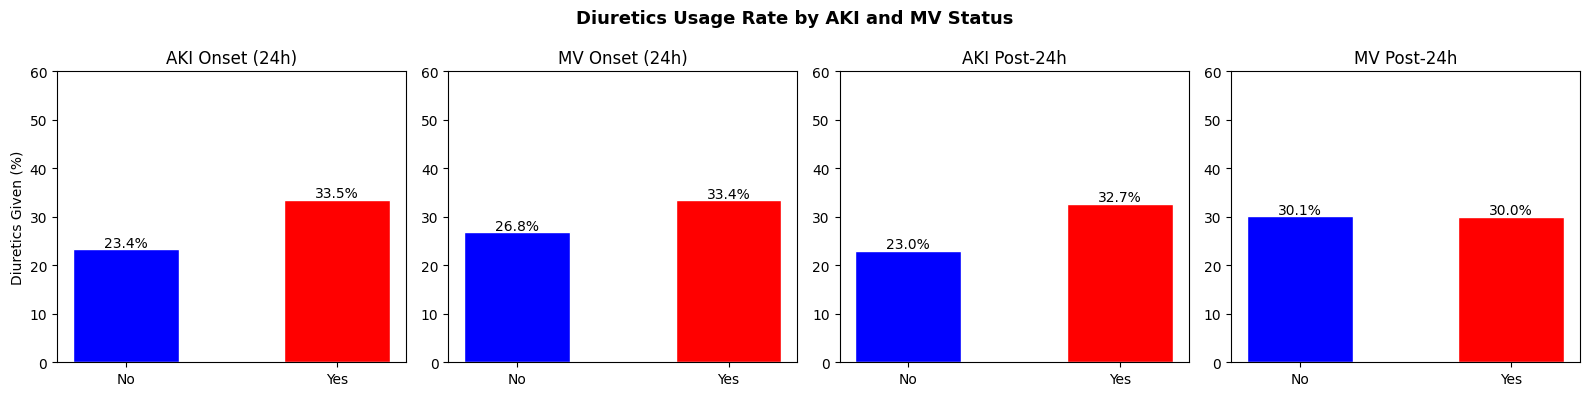

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Diuretics Usage Rate by AKI and MV Status", fontsize=13, fontweight="bold")

for ax, (outcome_label, outcome_col) in zip(axes, outcomes.items()):
    rates = df.groupby(outcome_col)["diuretics_given"].mean() * 100
    bars  = ax.bar(["No", "Yes"], rates.values,
                   color=["blue", "red"], edgecolor="white", width=0.5)
    ax.set_title(outcome_label)
    ax.set_ylabel("Diuretics Given (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 60)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f"{val:.1f}%", ha="center", fontsize=10)

plt.tight_layout()

plt.show()
fig.savefig("../diuretics_by_outcome.png", dpi=300)